In [1]:
import torch
from torch import nn
import torchvision.transforms as transforms
import pandas as pd
import sys
from pathlib import Path

labels = pd.read_csv('../cifar-10/trainLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, split_dataset

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=labels,
    transform=transforms.ToTensor()
)

train_dataset, val_dataset, test_dataset = split_dataset(
    dataset=train_dataset,
    train_size=int(0.8 * len(train_dataset)),
    val_size=int(0.1 * len(train_dataset)),
    test_size=int(0.1 * len(train_dataset))
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = create_dataloader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARBaseline
from src.metrics import create_metrics
from src.engine import fit

model = CIFARBaseline().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)
epochs = 10

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Baseline.pt'
)

history


Epoch 1/10:
Training Loss: 1.4990 | Training Accuracy: 45.03% | Training Precision: 44.31% | Training Recall: 45.03%
Validation Loss: 1.1503 | Validation Accuracy: 59.09% | Validation Precision: 60.24% | Validation Recall: 59.09%
Best model saved! Val Acc: 59.09%

Epoch 2/10:
Training Loss: 1.0313 | Training Accuracy: 63.39% | Training Precision: 63.03% | Training Recall: 63.39%
Validation Loss: 0.9559 | Validation Accuracy: 65.52% | Validation Precision: 66.59% | Validation Recall: 65.52%
Best model saved! Val Acc: 65.52%

Epoch 3/10:
Training Loss: 0.8215 | Training Accuracy: 71.28% | Training Precision: 71.08% | Training Recall: 71.28%
Validation Loss: 0.8334 | Validation Accuracy: 69.93% | Validation Precision: 69.98% | Validation Recall: 69.93%
Best model saved! Val Acc: 69.93%

Epoch 4/10:
Training Loss: 0.6721 | Training Accuracy: 76.33% | Training Precision: 76.22% | Training Recall: 76.33%
Validation Loss: 0.8514 | Validation Accuracy: 71.17% | Validation Precision: 72.65% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.499047,0.450344,0.443075,0.450344,1.150307,0.590867,0.602400,0.590867
1,2,1.031257,0.633860,0.630303,0.633860,0.955902,0.655186,0.665931,0.655186
2,3,0.821534,0.712783,0.710783,0.712783,0.833391,0.699280,0.699782,0.699280
3,4,0.672126,0.763285,0.762203,0.763285,0.851352,0.711689,0.726531,0.711689
4,5,0.539674,0.811322,0.810510,0.811322,0.819526,0.725750,0.729874,0.725750
5,6,0.419394,0.852196,0.851717,0.852196,0.874410,0.725733,0.730169,0.725733
6,7,0.321220,0.888167,0.887799,0.888167,0.968399,0.708380,0.717671,0.708380
7,8,0.246162,0.912592,0.912328,0.912592,1.140765,0.718745,0.731150,0.718745
8,9,0.192155,0.932912,0.932769,0.932912,1.266497,0.724689,0.725578,0.724689
9,10,0.157414,0.945791,0.945737,0.945791,1.329241,0.730388,0.730760,0.730388


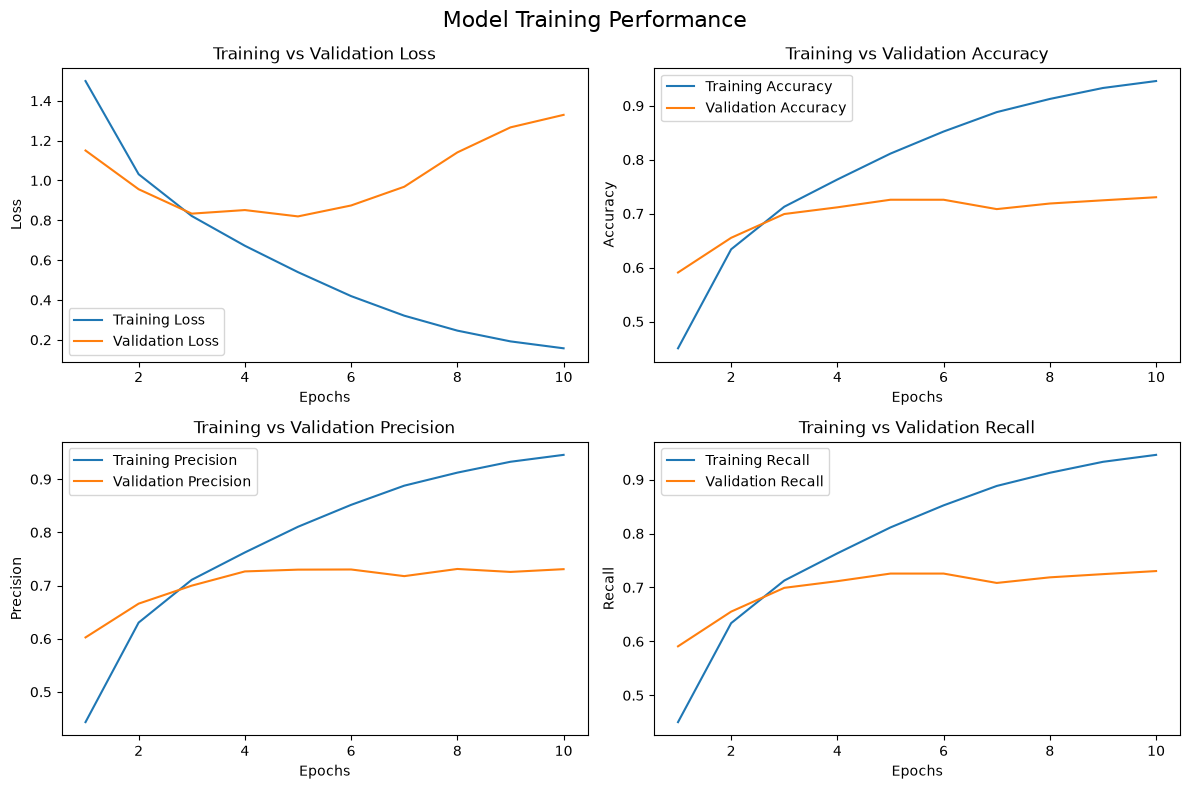

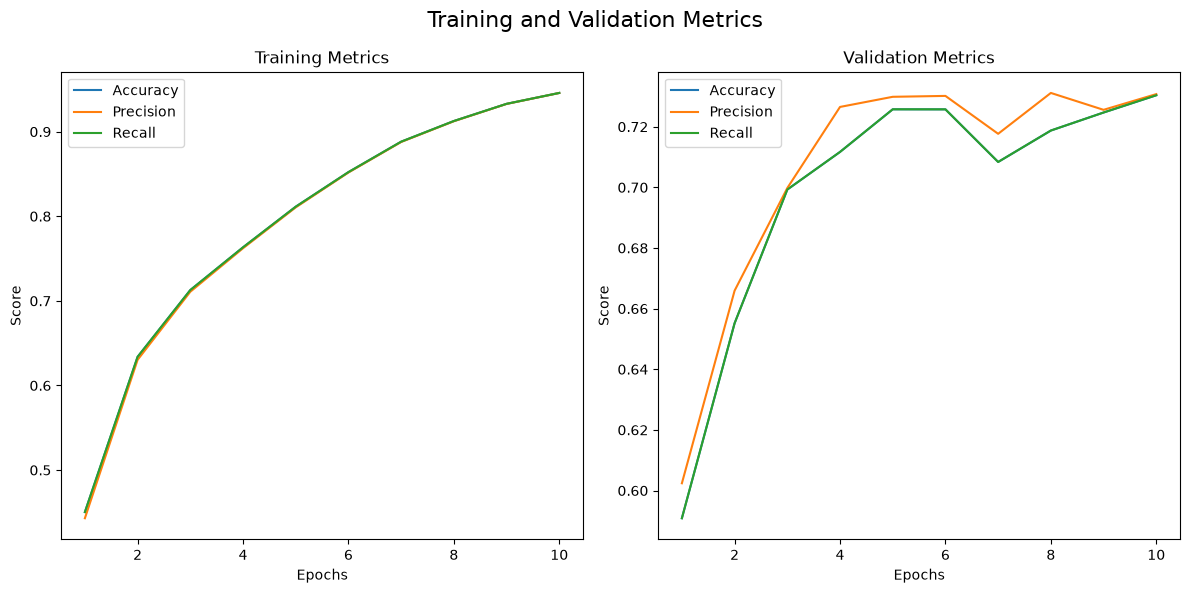

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)